# **Prerequisites**


> 1. Installing conda in colab (ne condacolab!)

> 2. Import clear_output (keeping colab neat!!!)

In [1]:
# !pip install -q condacolab
# import condacolab
# condacolab.install()

✨🍰✨ Everything looks OK!


In [2]:
# from IPython.display import clear_output


---

# 2. How to train a Deep learning model?  - Hands-on
    
---

In this tutorial, we will show you how to:


> 1. Train a Convolutional Neural Network (CNN) on MPRA data


> 2. Evaluate models








# STEP 1

## The Setup - Creating environment and installing dependencies

---




> Fetch our workshop repository from GitHub using `git clone`



In [1]:
!git clone https://github.com/kircherlab/HowToTrainDNN.git

Cloning into 'HowToTrainDNN'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 56 (delta 15), reused 20 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 26.64 MiB | 14.32 MiB/s, done.
Resolving deltas: 100% (15/15), done.


> You can see a folder `HowToTrainDNN` in your Files directory, if not please ask!

---


## Getting a deep neural network (DNN) model

---


>For e.g., how about DeepSTARR? From *Almeida et al., 2022*

>But do they have GitHub repo? - Duh!! offcourse :)





In [2]:
!git clone https://github.com/bernardo-de-almeida/DeepSTARR.git

Cloning into 'DeepSTARR'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (228/228), done.
remote: Compressing objects: 100% (170/170), done.
remote: Total 228 (delta 125), reused 160 (delta 57), pack-reused 0 (from 0)
Receiving objects: 100% (228/228), 4.52 MiB | 14.64 MiB/s, done.
Resolving deltas: 100% (125/125), done.


In [3]:
!cd DeepSTARR/DeepSTARR/

## Creating a conda environment

we create a `conda` environment for our DNN model using

```
conda create --name <name-of-environment> package=1 package=2 ...
```
> # 🛈 Note
>This step should take about 3-5 minutes.

---



In [7]:
# !conda create --name DeepSTARR python=3.7 tensorflow-gpu -y
# clear_output()

> Activate environment with `source activate <name-of-environment>`

---

In [3]:
# !source activate DeepSTARR

## Importing libraries

---

In [2]:
# DNN libraries
import tensorflow as tf
import keras
import keras.layers as kl
from keras.models import Sequential, Model, load_model
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping, History, ModelCheckpoint
from keras.layers import Conv1D, MaxPooling1D
from keras.layers import Dropout, Reshape, Dense, Activation, Flatten
from keras.layers import BatchNormalization, InputLayer, Input
from keras import models

# Data-analysis libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

# for reproduciblity
import random
random.seed(42)

# STEP 2


## The Data - Getting MPRA dataset

Here, we will use dataset from the following study.

*Agarwal, V., Inoue, F., Schubach, M., Martin, B.K., Dash, P.M., Zhang, Z., Sohota, A., Noble, W.S., Yardimci, G.G., Kircher, M. and Shendure, J., 2023. **Massively parallel characterization of transcriptional regulatory elements in three diverse human cell types**. bioRxiv.*

---

In [5]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# reading a .tsv file
activity_data = '/content/drive/MyDrive/PhD/neuro_activity_80K/tested_sequences_only_23790.tsv'
activity_data = '/home/kisa/coding/80K_MPRA/element_analysis_output/element_activity_prediction/tested_sequences_only_23790.tsv'

data = pd.read_csv(activity_data, sep='\t')
data.head()

,name,sequence,logFC
0,cardiac_neuro_cava_random:FGF12|ENSG0000011427...,AGGACCGGATCAACTAGTCTCTTAGTAATTATCTTGTGCACTATAC...,1.592724
1,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,AGGACCGGATCAACTAGGACAGAACTGTGTGCTGCCTGCTTCACTC...,1.633098
2,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,AGGACCGGATCAACTGGAAAACCATGCCCTCCAGGGACTGCACTAT...,2.089245
3,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,AGGACCGGATCAACTAATGTAGATTTATGACAGTTTTGAAAAATCA...,1.891649
4,cardiac_neuro_cava_random:RERE|ENSG00000142599...,AGGACCGGATCAACTTGTTATCACAGTTATTGTTTGTATGTGTGAT...,1.765055


### Remove adapter (+-15bp)

In [4]:
data['sequence_with_adapter'] = data['sequence']
data['sequence'] = data['sequence_with_adapter'].apply(lambda x: x[15:-15])

## Understanding data distribution

---

In [15]:
# # Set up the matplotlib figure
# fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

# for i, (col1, col2) in enumerate([(2, 3), (3, 4), (4, 2)]):
#     # Create a hexbin plot for the joint plot
#     hb = axes[i].hexbin(data.iloc[:, col1], data.iloc[:, col2], gridsize=50, extent=[-2, 2, -2, 2], cmap='Greys')

#     # Calculate and print the Pearson correlation coefficient and p-value
#     corr_coef, p_value = stats.pearsonr(data.iloc[:, col1], data.iloc[:, col2])
#     axes[i].text(-1.5, 1.5, f'pearsonr: {corr_coef:.2f}')

#     # Set the same axes limits for all subplots
#     axes[i].set_xlim([-2, 2])
#     axes[i].set_ylim([-2, 2])

#     # Set the axis labels
#     axes[i].set_xlabel(data.columns[col1])
#     axes[i].set_ylabel(data.columns[col2])

#     # Set ticks in axis per each integer
#     axes[i].set_xticks(np.arange(-2, 3, 1))
#     axes[i].set_yticks(np.arange(-2, 3, 1))

# plt.tight_layout()
# plt.show()

## One-hot encoding
> Let's understand how to one-hot-encode?

<img src="https://media.springernature.com/full/springer-static/image/art%3A10.1007%2Fs00449-022-02716-w/MediaObjects/449_2022_2716_Fig3_HTML.png?as=webp" alt="STARR-seq data" width="600"/>

[Reference](https://link.springer.com/article/10.1007/s00449-022-02716-w)

---

Are there only 4 DNA/RNA nucelotide base annotations?
> Duh! off course not :)

| IUPAC nucleotide code | Base                |
| --------------------- | ------------------- |
| A                     | Adenine             |
| C                     | Cytosine            |
| G                     | Guanine             |
| T (or U)              | Thymine (or Uracil) |
| R                     | A or G              |
| Y                     | C or T              |
| S                     | G or C              |
| W                     | A or T              |
| K                     | G or T              |
| M                     | A or C              |
| B                     | C or G or T         |
| D                     | A or G or T         |
| H                     | A or C or T         |
| V                     | A or C or G         |
| N                     | any base            |

[Source](https://www.bioinformatics.org/sms/iupac.html)

In [5]:
# define a dictionary to map nucleotides to their one-hot encoded representation
nucleotide_dict = {'A': [1, 0, 0, 0],
                   'C': [0, 1, 0, 0],
                   'G': [0, 0, 1, 0],
                   'T': [0, 0, 0, 1],
                   'N': [0, 0, 0, 0]} # what if there's an N

# define a function to one-hot encode a single DNA sequence
def one_hot_encode(seq):
    return np.array([nucleotide_dict[nuc] for nuc in seq])

## Train, test and validation split

---

> Let's split dataset as follows,
  - Input X: sequences as one-hot encoded
  - Output Y: mean MPRA activity (logFC)
  - Split:
    - 90% train
    - 5% test
    - 5% validation

In [6]:
def splitEncode(df, X_cols, y_cols):
    # Split the dataframe into X and y
    X = df[X_cols]
    y = df[y_cols]

    # One-hot encode the X data
    X = np.array(X['sequence'].apply(one_hot_encode).tolist())

    # Split the data into train and test+validation sets (90% and 10%)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.1, random_state=42)

    # Split the test+validation sets into test and validation sets (50% and 50% of 10% => 5% and 5% of total)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    return X_train, X_test, X_val, y_train, y_test, y_val


TODO: keep going

In [7]:
# let's split
X_train, X_test, X_val, y_train, y_test, y_val = splitEncode(data, ['sequence'], ['logFC'])
pd.DataFrame({
    'Dataset': ['X_train', 'X_test', 'X_val', 'y_train', 'y_test', 'y_val'],
    'Shape': [X_train.shape, X_test.shape, X_val.shape, y_train.shape, y_test.shape, y_val.shape]
})


,Dataset,Shape
0,X_train,"(21411, 270, 4)"
1,X_test,"(1189, 270, 4)"
2,X_val,"(1190, 270, 4)"
3,y_train,"(21411, 1)"
4,y_test,"(1189, 1)"
5,y_val,"(1190, 1)"


## Setting hyperparamters
> Here, we are going to use an optimized set of `params` (aka hyperparamters or model features) from the DeepSTARR study.

NOTE: Importance of hyperparamters
  - **Importance**: They define the model structure and learning process, significantly influencing performance.
  - **Achievement**: Set before training, determined by trial and error, or systematic search processes.
  - **Time**: Tuning hyperparameters is time-consuming as each configuration requires training a new model. Plan accordingly.

In [8]:
params = {'batch_size': 64, # number of examples per batch
                      'epochs': 10, # number of epochs
                      'early_stop': 10, # patience of 10 epochs to reduce training time; you can increase the patience to see if the model improves after more epochs
                      'lr': 0.001, # learning rate
                      'n_conv_layer': 3, # number of convolutional layers
                      'num_filters1': 128, # number of filters/kernels in the first conv layer
                      'num_filters2': 60, # number of filters/kernels in the second conv layer
                      'num_filters3': 60, # number of filters/kernels in the third conv layer
                      # 'num_filters4': 120,
                      'kernel_size1': 7, # size of the filters in the first conv layer
                      'kernel_size2': 3, # size of the filters in the second conv layer
                      'kernel_size3': 5, # size of the filters in the third conv layer
                      # 'kernel_size4': 3,
                      'n_dense_layer': 1, # number of dense/fully connected layers
                      'dense_neurons1': 64, # number of neurons in the dense layer
                      # 'dense_neurons2': 256,
                      'dropout_conv': 'yes', # add dropout after convolutional layers?
                      'dropout_prob': 0.4, # dropout probability
                      'pad':'same'}

## Model configuration - Setting input and output

> We will follow the DeepSTARR model structure.

In [9]:
### Additional metrics for training purpose
def Spearman(y_true, y_pred):
     return ( tf.py_function(spearmanr, [tf.cast(y_pred, tf.float32),
                       tf.cast(y_true, tf.float32)], Tout = tf.float32) )


In [10]:
def DeepSTARR(params):

    lr = params['lr']
    # expects sequences of length 270 with 4 channels, length of DNA sequences
    input = kl.Input(shape=(270, 4))

    # Body - 4 conv + batch normalization + ReLu activation + max pooling
    # The number of convolutional layers and their hyperparameters are determined by the values in the params dictionary.
    x = kl.Conv1D(params['num_filters1'], kernel_size=params['kernel_size1'],
                  padding=params['pad'],
                  name='Conv1D_1')(input)
    x = kl.BatchNormalization()(x)
    x = kl.Activation('relu')(x)
    x = kl.MaxPooling1D(2)(x)

    for i in range(1, params['n_conv_layer']):
        x = kl.Conv1D(params['num_filters'+str(i+1)],
                      kernel_size=params['kernel_size'+str(i+1)],
                      padding=params['pad'],
                      name=str('Conv1D_'+str(i+1)))(x)
        x = kl.BatchNormalization()(x)
        x = kl.Activation('relu')(x)
        x = kl.MaxPooling1D(2)(x)
        # add dropout after convolutional layers?
        if params['dropout_conv'] == 'yes': x = kl.Dropout(params['dropout_prob'])(x)

    # After the convolutional layers, the output is flattened and passed through a series of fully connected/dense layers
    # Flattening converts a multi-dimensional input (from the convolutions) into a one-dimensional array (to be connected with the fully connected layers
    x = kl.Flatten()(x)

    # Fully connected layers
    # Each fully connected layer is followed by batch normalization, ReLU activation, and dropout
    for i in range(0, params['n_dense_layer']):
        x = kl.Dense(params['dense_neurons'+str(i+1)],
                     name=str('Dense_'+str(i+1)))(x)
        x = kl.BatchNormalization()(x)
        x = kl.Activation('relu')(x)
        x = kl.Dropout(params['dropout_prob'])(x)

    # Main model bottleneck
    bottleneck = x

    # heads per task (developmental and housekeeping enhancer activities)
    tasks = ['logFC']
    outputs = []
    for task in tasks:
        outputs.append(kl.Dense(1, activation='linear', name=str('Dense_' + task))(bottleneck))

    model = keras.models.Model([input], outputs)
    model.compile(keras.optimizers.Adam(learning_rate=lr),
                  loss=['mse'], # loss
                  # loss_weights=[1], # loss weigths to balance
                  metrics=[Spearman]) # additional track metric

    return model, params

DeepSTARR(params)[0].summary()

ModuleNotFoundError: No module named 'keras.engine.base_layer_v1'

# STEP 3

---

## Training a DNN
> Now, we are ready to start model training.

In [24]:
!conda list | grep "keras"

In [20]:
def train(selected_model, X_train, Y_train, X_valid, Y_valid, params):

    my_history=selected_model.fit(X_train, Y_train,
                                  validation_data=(X_valid, Y_valid),
                                  batch_size=params['batch_size'], epochs=params['epochs'],
                                  callbacks=[EarlyStopping(patience=params['early_stop'], monitor="val_loss", restore_best_weights=True),
                                             History()])

    return selected_model, my_history

main_model, main_params = DeepSTARR(params)
main_model, my_history = train(main_model, X_train, y_train, X_val, y_val, main_params)

Epoch 1/10


ValueError: Cannot take the length of shape with unknown rank.

## Things to remember

---

# STEP 4

---

## Model evaluation

> It's time to evaluate our model.
  - Did it ***PASS***, or ***FAIL***, or the ***BEST***!

### Understand training

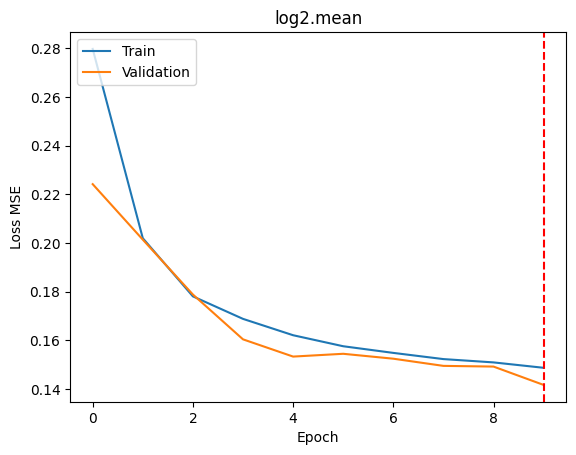

In [ ]:
# Plot training & validation training metrics
# MSE
plt.plot(my_history.history[str('loss')])
plt.plot(my_history.history[str('val_loss')])
plt.title('logFC') # loss is Mean Squared Error (MSE)
plt.ylabel('Loss MSE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Add vertical line at minimum validation loss of combined dev and hk
min_val_loss = min(my_history.history['val_loss'])
plt.axvline(x=my_history.history['val_loss'].index(min_val_loss), color='red', linestyle='--')

plt.show()

### Performance metrics

In [ ]:
def evaluate_model(X, y, model):
    # Predict the output
    y_pred = model.predict(X)
    # Reshape the arrays to be one-dimensional
    y = y.values.reshape(-1)
    y_pred = y_pred.reshape(-1)

    # Calculate metrics
    mse = mean_squared_error(y, y_pred)
    pcc, _ = pearsonr(y, y_pred)
    scc, _ = spearmanr(y, y_pred)

    # Create a DataFrame for the table
    metrics_df = pd.DataFrame({
        'Metric': ['MSE', 'PCC', 'SCC'],
        'Value': [mse, pcc, scc]
    })

    # Print the table
    print(metrics_df)

In [ ]:
evaluate_model(X_val, y_val, main_model)

351/351 [==============================] - 2s 3ms/step
  Metric     Value
0    MSE  0.141763
1    PCC  0.712808
2    SCC  0.652897


In [ ]:
evaluate_model(X_test, y_test, main_model)

351/351 [==============================] - 1s 2ms/step
  Metric     Value
0    MSE  0.136315
1    PCC  0.717152
2    SCC  0.658644


### Plotting data - A model perspective

176/176 [==============================] - 1s 3ms/step


<ipython-input-22-3282c777fc6f>:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "w" (-> color=(1.0, 1.0, 1.0, 1)). The keyword argument will take precedence.
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')


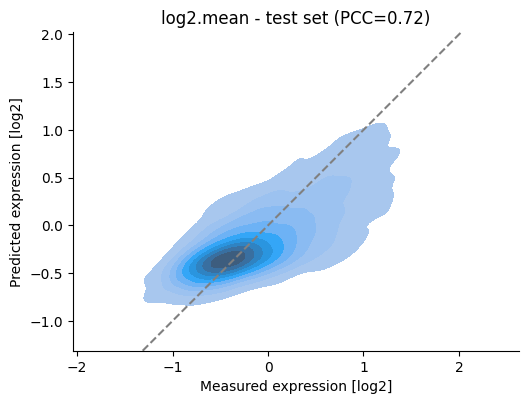

In [ ]:
### smoothscatter plot - useful when there are thousands of points

# takes some time to calculate the kernel density
def my_scatter_density(X, Y, set, task):
  pred = main_model.predict(X, batch_size=main_params['batch_size'])

  # Convert DataFrames to numpy arrays and reshape to be one-dimensional
  Y = Y.values.reshape(-1)
  pred = pred.reshape(-1)

  g = sns.jointplot(x=Y, y=pred, kind="kde", fill=True)
  g.ax_marg_x.remove() # remove marginal densities
  g.ax_marg_y.remove() # remove marginal densities

  # add expected regression line
  x0, x1 = g.ax_joint.get_xlim()
  y0, y1 = g.ax_joint.get_ylim()
  lims = [max(x0, y0), min(x1, y1)]
  g.ax_joint.plot(lims, lims, 'w', linestyle='dashed', transform=g.ax_joint.transData, color='grey')

  # same axes ranges
  g.ax_joint.set_aspect('equal')

  PCC = str("{0:0.2f}".format(stats.pearsonr(Y, pred)[0]))
  plt.xlabel('Measured expression [log2]')
  plt.ylabel('Predicted expression [log2]')
  plt.title(str(task + ' - ' + set + ' set (PCC=' + PCC + ')'))

  plt.show()

# print plots for test sets
my_scatter_density(X_test, y_test, "test", "logFC")

# Saving your model

---

In [ ]:
# save your model weights and structure as it is
main_model.save('my_DeepSTARR_model.h5')